In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import optuna
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import time
import torch
import random
import os
import torch.nn as nn
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim  # ✅ Добавить эту строку!
from torch.utils.data import DataLoader

# Подавление предупреждений
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore", category=FutureWarning, module='optuna')
warnings.filterwarnings("ignore", category=UserWarning, module='sklearn')

# --- Импорты для моделей ---
# Классификаторы
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier

# Регрессоры
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

C:\Users\l.d.lagunov\.conda\envs\pytorch_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


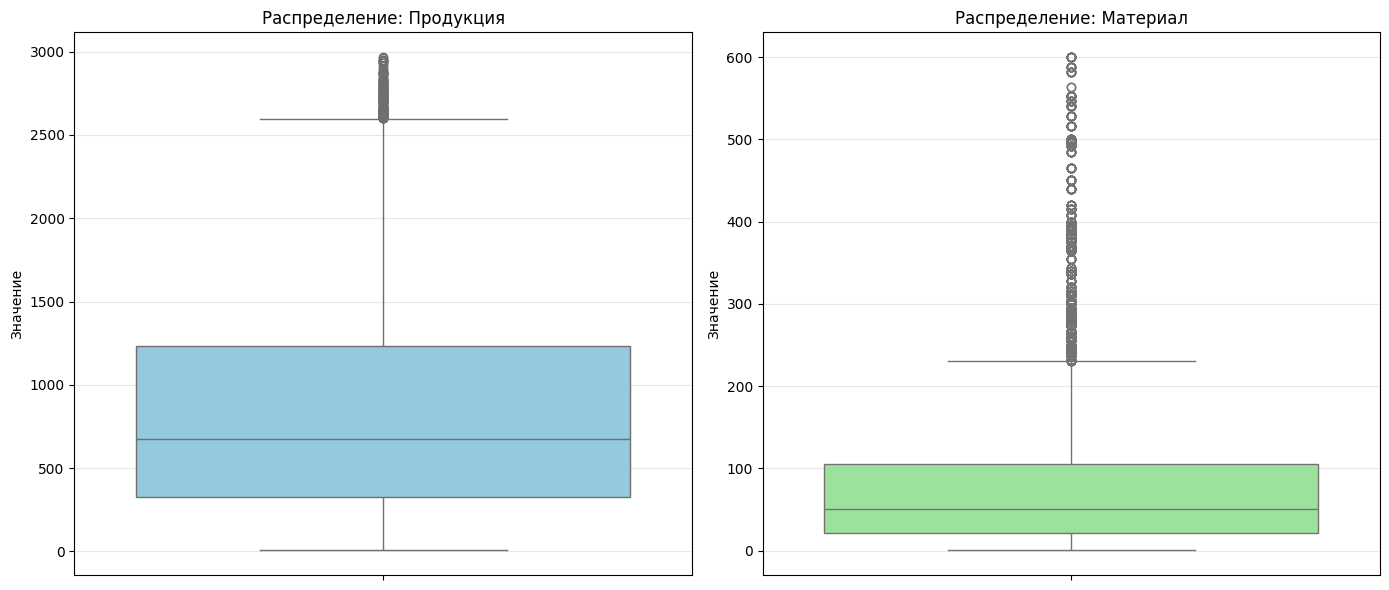

📈 Продукция:
count    13316.000000
mean       851.690823
std        637.695326
min          6.000000
25%        327.000000
50%        675.500000
75%       1234.000000
max       2968.000000
Name: Продукция, dtype: float64

📈 Материал:
count    13316.000000
mean        83.671835
std         96.947380
min          0.200000
25%         21.200000
50%         50.000000
75%        105.000000
max        600.000000
Name: Материал, dtype: float64


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("kalashnikov_task1/clear.csv")

# Предположим, ваш DataFrame называется df
# Создаем фигуру с двумя субплотами
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box plot для Продукция
sns.boxplot(y=df['Продукция'], ax=axes[0], color='skyblue')
axes[0].set_title('Распределение: Продукция')
axes[0].set_ylabel('Значение')
axes[0].grid(axis='y', alpha=0.3)

# Box plot для Материал
sns.boxplot(y=df['Материал'], ax=axes[1], color='lightgreen')
axes[1].set_title('Распределение: Материал')
axes[1].set_ylabel('Значение')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 📊 Статистика для интерпретации
print("📈 Продукция:")
print(df['Продукция'].describe())
print("\n📈 Материал:")
print(df['Материал'].describe())






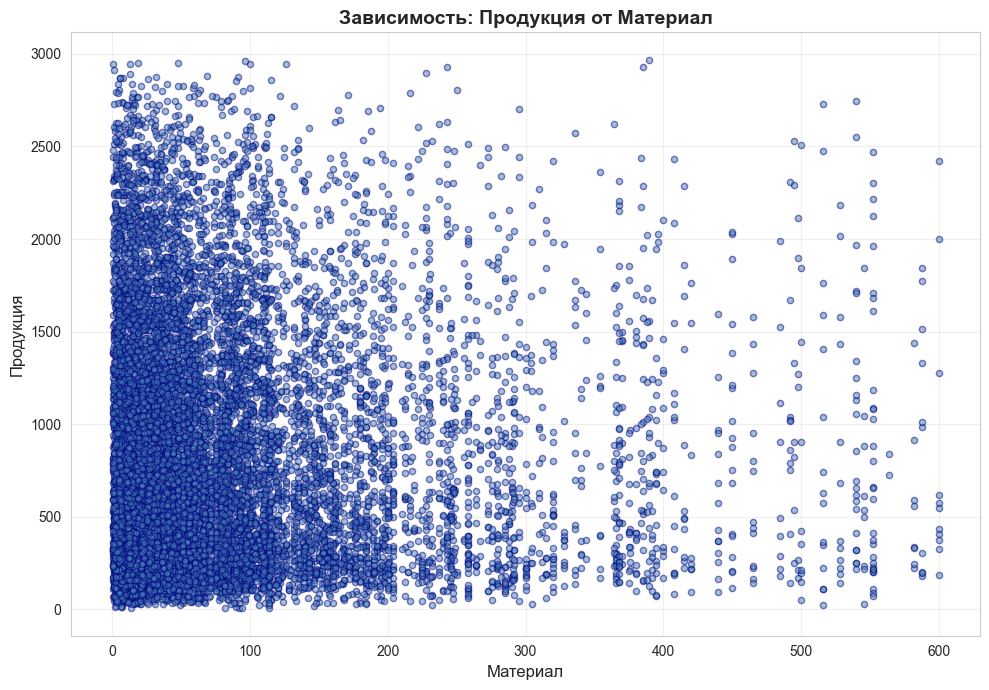

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля
sns.set_style("whitegrid")
plt.figure(figsize=(10, 7))

# Scatter plot: Материал (x) vs Продукция (y)
plt.scatter(df['Материал'], df['Продукция'], 
            alpha=0.5, s=20, c='steelblue', edgecolors='navy')

plt.xlabel('Материал', fontsize=12)
plt.ylabel('Продукция', fontsize=12)
plt.title('Зависимость: Продукция от Материал', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# --- Импорты для метрик ---
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score,
    mean_squared_error, mean_absolute_error, r2_score
)

# --- Бустинговые модели ---
try:
    from xgboost import XGBClassifier, XGBRegressor
    from lightgbm import LGBMClassifier, LGBMRegressor
    from catboost import CatBoostClassifier, CatBoostRegressor
    _BOOSTING_INSTALLED = True
except ImportError:
    _BOOSTING_INSTALLED = False
    print("⚠️ Бустинговые модели не установлены. pip install xgboost lightgbm catboost")


In [5]:
# ============================================================================
# ФУНКЦИЯ УДАЛЕНИЯ ВЫБРОСОВ (IQR МЕТОД)
# ============================================================================
def remove_outliers_iqr(df, target_column, columns=None, iqr_threshold=1.5, remove_from_target=True):
    """
    Удаляет выбросы из DataFrame с помощью метода IQR.
    :param df: исходный DataFrame
    :param target_column: название целевой переменной
    :param columns: список признаков для проверки. Если None, проверяются все числовые.
    :param iqr_threshold: множитель для IQR (стандартно 1.5, можно 3.0 для мягкой очистки)
    :param remove_from_target: bool, удалять ли выбросы по целевой переменной (для регрессии)
    :return: очищенный DataFrame
    """
    df_clean = df.copy()
    
    # Выбираем только числовые колонки
    if columns is None:
        numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    else:
        numeric_cols = [c for c in columns if c in df_clean.select_dtypes(include=[np.number]).columns]

    mask = pd.Series([True] * len(df_clean), index=df_clean.index)

    # Фильтрация по признакам
    for col in numeric_cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - iqr_threshold * IQR
        upper_bound = Q3 + iqr_threshold * IQR
        mask &= (df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)

    # Фильтрация по целевой переменной (только для регрессии)
    if remove_from_target and pd.api.types.is_numeric_dtype(df_clean[target_column]):
        Q1 = df_clean[target_column].quantile(0.25)
        Q3 = df_clean[target_column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - iqr_threshold * IQR
        upper_bound = Q3 + iqr_threshold * IQR
        mask &= (df_clean[target_column] >= lower_bound) & (df_clean[target_column] <= upper_bound)

    n_removed = len(df_clean) - mask.sum()
    df_clean = df_clean[mask].reset_index(drop=True)
    print(f"🧹 Удалено выбросов (IQR={iqr_threshold}): {n_removed} строк. Осталось: {len(df_clean)}")
    
    return df_clean

In [30]:
# ============================================================================
# КЛАСС Dataset
# ============================================================================
class Dataset:
    """
    Класс для загрузки, анализа и предобработки данных.
    Автоматически определяет тип задачи (классификация/регрессия).
    ✅ ИСПРАВЛЕНО: Теперь разделяет на train/validation/test (3 выборки)
    """

    def __init__(self, data_source, target_column, task_type=None, 
                 test_size=0.2, val_size=0.2, random_state=42, 
                 categorical_columns=None, one_hot_encoding=False):
        if isinstance(data_source, str):
            self.df = pd.read_csv(data_source)
        elif isinstance(data_source, pd.DataFrame):
            self.df = data_source
        else:
            raise ValueError("data_source должен быть путем к файлу или pandas DataFrame")

        self.target_column = target_column
        self.X = self.df.drop(columns=[self.target_column])
        self.y = self.df[self.target_column]

        self.task_type = task_type or self._infer_task_type()
        print(f"Определен тип задачи: {self.task_type}")

        if one_hot_encoding:
            self.one_hot_encoding(categorical_columns)
        
        # ✅ ИСПРАВЛЕНО: Разделение на 3 выборки (train/val/test)
        # Сначала отделяем тестовую выборку
        stratify = self.y if self.task_type == 'classification' and self.y.nunique() > 1 else None
        
        # test_size от общего объема данных
        self.X_train_val, self.X_test, self.y_train_val, self.y_test = train_test_split(
            self.X, self.y, test_size=test_size, random_state=random_state, stratify=stratify
        )
        
        # val_size от оставшихся данных (train_val)
        val_ratio = val_size / (1 - test_size)  # Конвертируем в долю от train_val
        stratify_train_val = self.y_train_val if self.task_type == 'classification' and self.y_train_val.nunique() > 1 else None
        
        self.X_train, self.X_val, self.y_train, self.y_val = train_test_split(
            self.X_train_val, self.y_train_val, 
            test_size=val_ratio, 
            random_state=random_state, 
            stratify=stratify_train_val
        )
        
        print(f"\n📊 Разделение данных:")
        print(f"   Обучающая выборка (train): {len(self.X_train)} samples ({len(self.X_train)/len(self.X)*100:.1f}%)")
        print(f"   Валидационная выборка (val): {len(self.X_val)} samples ({len(self.X_val)/len(self.X)*100:.1f}%)")
        print(f"   Тестовая выборка (test): {len(self.X_test)} samples ({len(self.X_test)/len(self.X)*100:.1f}%)")
        
        self.scaler = None

    def _infer_task_type(self):
        """Автоматически определяет тип задачи на основе целевой переменной."""
        if pd.api.types.is_float_dtype(self.y):
            return 'regression'
        if self.y.nunique() < 30 and self.y.nunique() / len(self.y) < 0.2:
            return 'classification'
        return 'regression'

    def scale_features(self, scale_target=False):
        """Масштабирует признаки с помощью StandardScaler."""
        self.scaler = StandardScaler()
        self.X_train = pd.DataFrame(self.scaler.fit_transform(self.X_train), columns=self.X.columns)
        self.X_val = pd.DataFrame(self.scaler.transform(self.X_val), columns=self.X.columns)
        self.X_test = pd.DataFrame(self.scaler.transform(self.X_test), columns=self.X.columns)
    
        # ⚠️ Для регрессии y обычно не масштабируют (только для нейросетей иногда)
        if scale_target and self.task_type == 'regression':
            self.y_scaler = StandardScaler()
            self.y_train = self.y_scaler.fit_transform(self.y_train.values.reshape(-1, 1)).flatten()
            self.y_val = self.y_scaler.transform(self.y_val.values.reshape(-1, 1)).flatten()
            self.y_test = self.y_scaler.transform(self.y_test.values.reshape(-1, 1)).flatten()
            print("✅ Признаки и целевая переменная были масштабированы.")
        else:
            # ✅ Просто конвертируем в numpy array для совместимости
            self.y_train = self.y_train.values
            self.y_val = self.y_val.values
            self.y_test = self.y_test.values
            print("✅ Признаки были масштабированы (целевая переменная без изменений).")

    def plot_correlation_matrix(self, include_target=True, figsize=(10, 8), annot=True, cmap='coolwarm'):
        """Строит и отображает матрицу корреляций для признаков."""
        if include_target:
            df_for_corr = self.df.copy()
            if self.task_type == 'classification' and not pd.api.types.is_numeric_dtype(df_for_corr[self.target_column]):
                warnings.warn("Целевая переменная является категориальной.")
        else:
            df_for_corr = self.X.copy()
            
        correlation_matrix = df_for_corr.corr()

        plt.figure(figsize=figsize)
        sns.heatmap(correlation_matrix, annot=annot, cmap=cmap, fmt=".2f", linewidths=.5)
        plt.title('Матрица корреляций признаков' + (' (с целевой переменной)' if include_target else ''))
        plt.show()

    def one_hot_encoding(self, categorical_columns):
        df = self.X.copy()

        if categorical_columns is None:
            categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

        # Фильтруем только существующие колонки
        cols_to_encode = [col for col in categorical_columns if col in df.columns]

        if not cols_to_encode:
            print("⚠️ Нет колонок для one-hot encoding.")
            return

        # ✅ КЛЮЧЕВОЕ ИСПРАВЛЕНИЕ: принудительно меняем тип на category
        df[cols_to_encode] = df[cols_to_encode].astype('category')
        print(f"✅ Колонки конвертированы в category: {cols_to_encode}")

        # Кодируем
        df_encoded = pd.get_dummies(df, columns=cols_to_encode, drop_first=False)
        
        print(f"📊 Размерность: {df.shape} → {df_encoded.shape} (+{df_encoded.shape[1] - df.shape[1]} колонок)")
        self.X = df_encoded

    

    def X_count(self):
        return len(self.X.columns)

    def to_tensors(self, device='cpu'):
        """Конвертирует данные в torch.Tensor"""
        return {
            'X_train': torch.FloatTensor(self.X_train.values).to(device),
            'y_train': torch.FloatTensor(self.y_train.values).view(-1, 1).to(device),
            'X_val': torch.FloatTensor(self.X_val.values).to(device),
            'y_val': torch.FloatTensor(self.y_val.values).view(-1, 1).to(device),
            'X_test': torch.FloatTensor(self.X_test.values).to(device),
            'y_test': torch.FloatTensor(self.y_test.values).view(-1, 1).to(device),
        }

    def print_info(self, split='full', show_head=True, show_missing=True, show_stats=True):
        """
        Выводит подробную информацию о выбранной части датасета (train/val/test/full).
        :param split: 'train' | 'val' | 'test' | 'full' — какую выборку анализировать
        :param show_head: показать первые строки
        :param show_missing: показать статистику пропусков
        :param show_stats: показать описательную статистику
        """
        # 🔹 Выбираем данные в зависимости от split
        if split == 'full':
            X_part = self.df.drop(columns=[self.target_column]) if self.target_column in self.df.columns else self.df
            y_part = self.df[self.target_column] if self.target_column in self.df.columns else None
            title = "ВЕСЬ ДАТАСЕТ"
        elif split == 'train':
            X_part = self.X_train
            y_part = self.y_train
            title = "ОБУЧАЮЩАЯ ВЫБОРКА (train)"
        elif split == 'val':
            X_part = self.X_val
            y_part = self.y_val
            title = "ВАЛИДАЦИОННАЯ ВЫБОРКА (val)"
        elif split == 'test':
            X_part = self.X_test
            y_part = self.y_test
            title = "ТЕСТОВАЯ ВЫБОРКА (test)"
        else:
            raise ValueError("split должен быть: 'full', 'train', 'val' или 'test'")
        
        # 🔹 Собираем полный DataFrame для анализа
        if y_part is not None:
            # Конвертируем y в Series с правильным индексом, если это массив
            if isinstance(y_part, np.ndarray):
                y_part = pd.Series(y_part, name=self.target_column, index=X_part.index)
            df_part = pd.concat([X_part, y_part], axis=1)
        else:
            df_part = X_part.copy()
        
        print(f"\n{'='*70}")
        print(f"📋 {title}")
        print(f"{'='*70}")
        
        # Базовая информация
        print(f"\n📐 Размерность: {df_part.shape[0]} строк × {df_part.shape[1]} колонок")
        print(f"🎯 Целевая переменная: '{self.target_column}' (задача: {self.task_type})")
        
        # Типы данных
        print(f"\n📦 Типы данных:")
        dtype_counts = df_part.dtypes.value_counts()
        for dtype, count in dtype_counts.items():
            print(f"   {dtype}: {count} колонки(ок)")
        
        # Пропуски
        if show_missing:
            missing = df_part.isnull().sum()
            missing = missing[missing > 0]
            if len(missing) > 0:
                print(f"\n⚠️ Пропущенные значения:")
                for col, count in missing.items():
                    pct = count / len(df_part) * 100
                    print(f"   {col}: {count} ({pct:.2f}%)")
            else:
                print(f"\n✅ Пропущенных значений нет")
        
        # Дубликаты
        duplicates = df_part.duplicated().sum()
        if duplicates > 0:
            print(f"\n⚠️ Найдено дубликатов строк: {duplicates} ({duplicates/len(df_part)*100:.2f}%)")
        else:
            print(f"\n✅ Дубликатов строк нет")
        
        # Описательная статистика
        if show_stats:
            print(f"\n📊 Описательная статистика (числовые признаки):")
            numeric_df = df_part.select_dtypes(include=[np.number])
            if len(numeric_df.columns) > 0:
                stats = numeric_df.describe().T
                stats['missing'] = df_part[stats.index].isnull().sum()
                stats['unique'] = df_part[stats.index].nunique()
                print(stats[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'missing', 'unique']].to_string())
            else:
                print("   (нет числовых признаков)")
        
        # Первые строки
        if show_head:
            print(f"\n🔍 Первые 5 строк ({split}):")
            print(df_part.head().to_string())
        
        print(f"\n{'='*70}\n")


    def boxplot(self, split='full', figsize=(12, 5), show_stats=True):
        """
        Строит boxplot только для колонок 'Материал' и 'Продукция' на выбранной выборке.
        :param split: 'train' | 'val' | 'test' | 'full' — какую выборку использовать
        :param figsize: размер фигуры (ширина, высота)
        :param show_stats: показывать текстовую статистику под графиками
        """
        # 🔹 Выбираем данные в зависимости от split
        if split == 'full':
            X_part = self.df.drop(columns=[self.target_column]) if self.target_column in self.df.columns else self.df
            y_part = self.df[self.target_column] if self.target_column in self.df.columns else None
            title_suffix = "(весь датасет)"
        elif split == 'train':
            X_part = self.X_train
            y_part = self.y_train
            title_suffix = "(train)"
        elif split == 'val':
            X_part = self.X_val
            y_part = self.y_val
            title_suffix = "(validation)"
        elif split == 'test':
            X_part = self.X_test
            y_part = self.y_test
            title_suffix = "(test)"
        else:
            raise ValueError("split должен быть: 'full', 'train', 'val' или 'test'")
        
        # 🔹 Собираем DataFrame и добавляем целевую переменную
        if y_part is not None:
            if isinstance(y_part, np.ndarray):
                y_part = pd.Series(y_part, name=self.target_column, index=X_part.index)
            df_plot = pd.concat([X_part, y_part], axis=1)
        else:
            df_plot = X_part.copy()
        
        # 🔹 Жёстко задаём колонки для отображения
        cols_to_plot = ['Материал', 'Продукция']
        # Оставляем только те, что есть в данных и являются числовыми
        cols_to_plot = [c for c in cols_to_plot if c in df_plot.columns and pd.api.types.is_numeric_dtype(df_plot[c])]
        
        if not cols_to_plot:
            print("⚠️ Колонки 'Материал' и/или 'Продукция' не найдены или не являются числовыми")
            return
        
        # 🔹 Строим графики
        fig, axes = plt.subplots(1, len(cols_to_plot), figsize=figsize)
        if len(cols_to_plot) == 1:
            axes = [axes]
        
        for idx, col in enumerate(cols_to_plot):
            ax = axes[idx]
            
            # Boxplot
            sns.boxplot(y=df_plot[col], ax=ax, color='skyblue', showfliers=True)
            ax.set_title(f'{col} {title_suffix}', fontsize=12, fontweight='bold')
            ax.set_ylabel('Значение')
            ax.grid(axis='y', alpha=0.3, linestyle='--')
            
            # Линии среднего и медианы
            mean_val = df_plot[col].mean()
            median_val = df_plot[col].median()
            ax.axhline(mean_val, color='red', linestyle='--', linewidth=1, label=f'μ={mean_val:.2f}')
            ax.axhline(median_val, color='green', linestyle='-.', linewidth=1, label=f'med={median_val:.2f}')
            ax.legend(fontsize=9, loc='best')
            
            # 📊 Подсчёт выбросов (1.5×IQR)
            Q1 = df_plot[col].quantile(0.25)
            Q3 = df_plot[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            outliers = df_plot[(df_plot[col] < lower_bound) | (df_plot[col] > upper_bound)]
            outlier_pct = len(outliers) / len(df_plot) * 100
            
            # Подпись с % выбросов
            ax.text(0.02, 0.98, f'🔻 Выбросы: {len(outliers)} ({outlier_pct:.1f}%)', 
                   transform=ax.transAxes, fontsize=9, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))
        
        plt.suptitle(f'📦 Boxplot: Материал и Продукция', fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()
        
        # 📊 Текстовая статистика
        if show_stats:
            print(f"\n📈 Статистика для {title_suffix}:")
            print(f"{'Колонка':<15} {'Mean':>10} {'Med':>10} {'Std':>10} {'Min':>10} {'Max':>10} {'Outliers':>12}") 
            print("-" * 70)
            for col in cols_to_plot:
                Q1 = df_plot[col].quantile(0.25)
                Q3 = df_plot[col].quantile(0.75)
                IQR = Q3 - Q1
                lower = Q1 - 1.5 * IQR
                upper = Q3 + 1.5 * IQR
                outliers = df_plot[(df_plot[col] < lower) | (df_plot[col] > upper)]
                print(f"{col:<15} "
                      f"{df_plot[col].mean():>10.2f} "
                      f"{df_plot[col].median():>10.2f} " 
                      f"{df_plot[col].std():>10.2f} "
                      f"{df_plot[col].min():>10.2f} "
                      f"{df_plot[col].max():>10.2f} "
                      f"{len(outliers):>6} ({len(outliers)/len(df_plot)*100:5.1f}%)")



In [7]:
# ============================================================================
# КЛАСС ModelFactory 
# ============================================================================
class ModelFactory:
    """Фабрика для создания моделей в зависимости от типа задачи."""
    _classification_models = {
        "knn": KNeighborsClassifier, 
        "svm": SVC, 
        "naive_bayes": GaussianNB,
        "logistic_regression": LogisticRegression, 
        "random_forest": RandomForestClassifier,
        "ridge_classifier": RidgeClassifier
    }
    _regression_models = {
        "linear_regression": LinearRegression, 
        "ridge": Ridge, 
        "lasso": Lasso,
        "knn": KNeighborsRegressor, 
        "svm": SVR, 
        "random_forest": RandomForestRegressor,
    }

    if _BOOSTING_INSTALLED:
        _classification_models.update({
            "xgboost": XGBClassifier, 
            "lightgbm": LGBMClassifier, 
            "catboost": CatBoostClassifier,
        })
        _regression_models.update({
            "xgboost": XGBRegressor, 
            "lightgbm": LGBMRegressor, 
            "catboost": CatBoostRegressor,
        })

    @staticmethod
    def get_model(model_name, task_type, params=None):
        models_dict = ModelFactory._regression_models if task_type == 'regression' else ModelFactory._classification_models
        
        if model_name not in models_dict:
            if model_name in ["xgboost", "lightgbm", "catboost"]:
                raise ValueError(f"Модель '{model_name}' не установлена.")
            raise ValueError(f"Модель '{model_name}' не поддерживается для задачи '{task_type}'.")
        
        model_class = models_dict[model_name]
        params = params.copy() if params else {}
        
        if task_type == 'classification' and model_name == 'svm' and params.get('probability') is None:
            params['probability'] = True

        if model_name == "random_forest" and "learning_rate" in params:
            del params["learning_rate"]
            
        return model_class(**params)

In [8]:
# ============================================================================
# КЛАСС MetaModel
# ============================================================================
class MetaModel:
    """Мета-класс с поддержкой GPU для совместимых моделей."""
    
    def __init__(self, dataset: Dataset, model_name: str, model_params="optuna", use_gpu=True):
        self.dataset = dataset
        self.model_name = model_name
        self.model_params = model_params
        self.task_type = dataset.task_type
        self.model = None
        self.best_params_ = None
        self.use_gpu = use_gpu and torch.cuda.is_available()
        self.train_loss_history = {}  
        self.val_loss_history = {}   
        
        if self.use_gpu:
            print(f"🚀 Используется GPU: {torch.cuda.get_device_name(0)}")
        else:
            print("💻 Используется CPU")

    def _get_gpu_params(self, params):
        """Добавляет GPU параметры для соответствующих моделей."""
        if not self.use_gpu:
            return params
        
        params = params.copy()
            
        if self.model_name == 'xgboost':
            params['device'] = 'cuda:0'
            params['tree_method'] = 'hist'
            
        elif self.model_name == 'lightgbm':
            params['device'] = 'gpu'
            params['gpu_platform_id'] = 0
            params['gpu_device_id'] = 0
            
        elif self.model_name == 'catboost':
            params['task_type'] = 'GPU'
            params['devices'] = '0'
        
        return params

    def _objective(self, trial):
        is_classification = self.task_type == 'classification'
        train_losses = []
        val_losses = []
    
        # ✅ XGBoost
        if self.model_name == 'xgboost':
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
                'max_depth': trial.suggest_int('max_depth', 3, 12),
                'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
                'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            }
            params = self._get_gpu_params(params)
            model = ModelFactory.get_model(self.model_name, self.task_type, params)
        
            eval_set = [(self.dataset.X_train, self.dataset.y_train), 
                   (self.dataset.X_val, self.dataset.y_val)]
            model.fit(self.dataset.X_train, self.dataset.y_train, eval_set=eval_set, verbose=False)
        
            results = model.evals_result()
            # Получаем имя метрики динамически
            metric_name = list(results['validation_1'].keys())[0]
            train_losses = results['validation_0'][metric_name]
            val_losses = results['validation_1'][metric_name]
            val_pred = model.predict(self.dataset.X_val)
        
        # ✅ LightGBM
        elif self.model_name == 'lightgbm':
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
                'max_depth': trial.suggest_int('max_depth', 3, 12),
                'num_leaves': trial.suggest_int('num_leaves', 20, 300),
                'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
                'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                'verbose': -1,
            }
            params = self._get_gpu_params(params)
            model = ModelFactory.get_model(self.model_name, self.task_type, params)

            # ✅ Обучаем с eval_set
            model.fit(
                self.dataset.X_train, 
                self.dataset.y_train,
                eval_set=[(self.dataset.X_val, self.dataset.y_val)],
            )

            # ✅ ИЗВЛЕЧЕНИЕ ИСТОРИИ — ИСПРАВЛЕННАЯ ВЕРСИЯ
            if hasattr(model, 'evals_result_'):
                evals_result = model.evals_result_
                # Получаем имя метрики из keys()
                metric_name = list(evals_result['valid_0'].keys())[0]  # Берём первую доступную метрику
                val_losses = evals_result['valid_0'][metric_name]
                train_losses = val_losses  # Упрощенно, т.к. train не в eval_set

            val_pred = model.predict(self.dataset.X_val)
        
        # ✅ CatBoost
        elif self.model_name == 'catboost':
            params = {
                'iterations': trial.suggest_int('iterations', 100, 1000),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
                'depth': trial.suggest_int('depth', 4, 10),
                'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 30),
                'verbose': 0,
            }
            params = self._get_gpu_params(params)
            model = ModelFactory.get_model(self.model_name, self.task_type, params)
        
            model.fit(self.dataset.X_train, self.dataset.y_train, 
            eval_set=(self.dataset.X_val, self.dataset.y_val), verbose=False)
        
            if hasattr(model, 'evals_result_'):
                evals_result = model.evals_result_
                # CatBoost: 'learn' и 'validation' — словари с метриками
                metric_name = list(evals_result['validation'].keys())[0]
                val_losses = evals_result['validation'][metric_name]
                train_losses = evals_result['learn'][metric_name]
            val_pred = model.predict(self.dataset.X_val)
        
        # ✅ Остальные модели (Random Forest, KNN, SVM)
        else:
            params = {}
            if self.model_name == 'random_forest':
                params = {
                    'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
                    'max_depth': trial.suggest_int('max_depth', 3, 20),
                    'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
                    'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
                    'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
                }
            elif self.model_name == 'knn':
                params = {
                    'n_neighbors': trial.suggest_int('n_neighbors', 3, 50),
                    'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
                    'metric': trial.suggest_categorical('metric', ['minkowski', 'euclidean']),
                    'p': trial.suggest_int('p', 1, 3),
                }
            elif self.model_name == 'svm':
                C = trial.suggest_float("C", 1e-3, 1e3, log=True)
                kernel = trial.suggest_categorical("kernel", ["linear", "rbf", "poly"])
                gamma = trial.suggest_float("gamma", 1e-4, 1e-1, log=True) if kernel in ["rbf", "poly"] else "scale"
                params = {"C": C, "kernel": kernel, "gamma": gamma}
                if is_classification:
                    params["probability"] = True
        
            model = ModelFactory.get_model(self.model_name, self.task_type, params)
            model.fit(self.dataset.X_train, self.dataset.y_train)
        
            train_pred = model.predict(self.dataset.X_train)
            val_pred = model.predict(self.dataset.X_val)
        
            if self.task_type == 'regression':
                train_losses = [mean_squared_error(self.dataset.y_train, train_pred)]
                val_losses = [mean_squared_error(self.dataset.y_val, val_pred)]
            else:
                train_losses = [1 - f1_score(self.dataset.y_train, train_pred, average='macro')]
                val_losses = [1 - f1_score(self.dataset.y_val, val_pred, average='macro')]

        # ✅ СОХРАНЯЕМ ИСТОРИЮ В TRIAL
        trial.set_user_attr('train_losses', train_losses)
        trial.set_user_attr('val_losses', val_losses)
    
        # ✅ Финальная метрика
        if is_classification:
            score = f1_score(self.dataset.y_val, val_pred, average='macro')
        else:
            score = -mean_squared_error(self.dataset.y_val, val_pred)
    
        return score

    def train(self, n_trials=50):
        print(f"\n{'='*60}")
        print(f"🚀 Обучение модели: {self.model_name} для задачи {self.task_type}")
        print(f"{'='*60}")
        
        if self.model_params == "optuna":
            direction = "maximize"
            print(f"🔍 Запуск Optuna ({n_trials} итераций)...")

            study = optuna.create_study(direction=direction)
            study.optimize(self._objective, n_trials=n_trials, show_progress_bar=True)
            self.study = study 
            self._extract_loss_history(study)  
            
            self.best_params_ = study.best_params
            print(f"\n✅ Лучшие гиперпараметры найдены:")
            for param, value in self.best_params_.items():
                print(f"   {param}: {value}")
            
            best_trial = study.best_trial
            if "train_time" in best_trial.user_attrs:
                print(f"   ⏱️ Время обучения лучшего trials: {best_trial.user_attrs['train_time']:.2f} сек")
            
            best_params_with_gpu = self._get_gpu_params(self.best_params_.copy())
            self.model = ModelFactory.get_model(self.model_name, self.task_type, best_params_with_gpu)
        else:
            print("📋 Использование заданных гиперпараметров")
            params_with_gpu = self._get_gpu_params(self.model_params.copy() if self.model_params else {})
            self.model = ModelFactory.get_model(self.model_name, self.task_type, params_with_gpu)

        # ✅ Финальное обучение на train + val вместе (или только на train)
        start_time = time.time()
        self.model.fit(self.dataset.X_train, self.dataset.y_train)
        train_time = time.time() - start_time
        
        print(f"✅ Модель успешно обучена за {train_time:.2f} сек")
        
        if self.use_gpu and self.model_name in ['xgboost', 'lightgbm', 'catboost']:
            print(f"🎮 Обучение происходило на GPU")

    def _extract_loss_history(self, study):
        """Извлекает историю потерь из всех завершенных trials"""
        for trial in study.trials:
            if trial.state == optuna.trial.TrialState.COMPLETE:
                train_losses = trial.user_attrs.get('train_losses', [])
                val_losses = trial.user_attrs.get('val_losses', [])
                if train_losses and val_losses:
                    self.train_loss_history[trial.number] = train_losses
                    self.val_loss_history[trial.number] = val_losses
        print(f"📊 История потерь сохранена для {len(self.train_loss_history)} trials")

    def get_best_trial_history(self):
        """Возвращает историю потерь лучшего trial"""
        if not self.study:
            return None, None
        best_trial_num = self.study.best_trial.number
        train_loss = self.train_loss_history.get(best_trial_num, [])
        val_loss = self.val_loss_history.get(best_trial_num, [])
        return train_loss, val_loss

    def evaluate(self):
        """
        ✅ ИСПРАВЛЕНО: Оценка только на тестовой выборке (финальная)
        """
        if self.model is None:
            raise RuntimeError("Модель не обучена. Вызовите метод train() перед оценкой.")
        
        print(f"\n--- Оценка модели {self.model_name} на TEST выборке ---")
        y_pred = self.model.predict(self.dataset.X_test)
        
        if self.task_type == 'classification':
            print("Отчет по классификации на тестовой выборке:")
            print(classification_report(self.dataset.y_test, y_pred))
            accuracy = accuracy_score(self.dataset.y_test, y_pred)
            f1 = f1_score(self.dataset.y_test, y_pred, average='macro')
            print(f"  Accuracy: {accuracy:.4f}")
            print(f"  Macro F1-Score: {f1:.4f}")
            return (accuracy, f1)
        else: 
            print("Метрики регрессии на тестовой выборке:")
            r2 = r2_score(self.dataset.y_test, y_pred)
            mse = mean_squared_error(self.dataset.y_test, y_pred) 
            mae = mean_absolute_error(self.dataset.y_test, y_pred)
            print(f"  R² (коэффициент детерминации): {r2:.4f}")
            print(f"  MSE (среднеквадратичная ошибка): {mse:.4f}")
            print(f"  MAE (средняя абсолютная ошибка): {mae:.4f}")
            return (r2, mse, mae)



In [9]:
# ============================================================================
# НЕЙРОСЕТЬ MLP
# ============================================================================
class MLP(nn.Module):
    def __init__(self, input_dim, dropout_rate=0.2):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),  
            nn.ReLU(),
            nn.Dropout(dropout_rate),  # ✅ Dropout после 1-го скрытого слоя
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),        # ✅ Добавил BN для стабильности
            nn.ReLU(),
            nn.Dropout(dropout_rate),  # ✅ Dropout после 2-го скрытого слоя
            
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),  # ✅ Dropout после 3-го скрытого слоя
            
            nn.Linear(32, 1)           # ✅ Выходной слой (без Dropout и активации для регрессии)
        )
    
    def forward(self, x):
        return self.network(x)

In [10]:
def set_seed(seed=42):
    """Фиксирует все генераторы случайных чисел"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"✅ Seed установлен: {seed}")

In [11]:
def evaluate_pytorch_model(model, X_test, y_test, task_type='regression'):
    """Вычисляет метрики для PyTorch модели"""
    model.eval()
    with torch.no_grad():
        if isinstance(X_test, pd.DataFrame):
            X_test = torch.FloatTensor(X_test.values)
        if isinstance(y_test, pd.Series):
            y_test = torch.FloatTensor(y_test.values).view(-1, 1)
        
        predictions = model(X_test)
        y_pred = predictions.numpy().flatten()
        y_true = y_test.flatten()
        
        if task_type == 'regression':
            r2 = r2_score(y_true, y_pred)
            mse = mean_squared_error(y_true, y_pred)
            mae = mean_absolute_error(y_true, y_pred)
            rmse = np.sqrt(mse)
            
            print(f"\n🧠 Метрики нейросети (регрессия):")
            print(f"  R²:  {r2:.4f}")
            print(f"  MSE: {mse:.4f}")
            print(f"  RMSE: {rmse:.4f}")
            print(f"  MAE: {mae:.4f}")
            return {'r2': r2, 'mse': mse, 'rmse': rmse, 'mae': mae}
        else:
            acc = accuracy_score(y_true, y_pred.round())
            f1 = f1_score(y_true, y_pred.round(), average='macro')
            print(f"\n🧠 Метрики нейросети (классификация):")
            print(f"  Accuracy: {acc:.4f}")
            print(f"  Macro F1: {f1:.4f}")
            return {'accuracy': acc, 'f1': f1}

In [24]:
# ============================================================================
# 🚀 ОСНОВНОЙ КОД
# ============================================================================

set_seed(42)

# Загрузка данных
df = pd.read_csv("kalashnikov_task1/clear.csv")

# 2️⃣ ✅ УДАЛЕНИЕ ВЫБРОСОВ (вызывается ДО создания Dataset и разбиения)
# iqr_threshold=1.5 → строгая очистка, 3.0 → мягкая
df = remove_outliers_iqr(
    df, 
    target_column="Продукция", 
    iqr_threshold=1.5, 
    remove_from_target=True  # Удалять экстремумы и в целевой переменной
)


✅ Seed установлен: 42
🧹 Удалено выбросов (IQR=1.5): 1340 строк. Осталось: 11976


Определен тип задачи: regression
✅ Колонки конвертированы в category: ['Цех', 'id документа_prod', 'id документа_cons', 'Артикул продукции', 'Артикул материала']
📊 Размерность: (11976, 13) → (11976, 12803) (+12790 колонок)

📊 Разделение данных:
   Обучающая выборка (train): 7185 samples (60.0%)
   Валидационная выборка (val): 2395 samples (20.0%)
   Тестовая выборка (test): 2396 samples (20.0%)
✅ Признаки были масштабированы (целевая переменная без изменений).


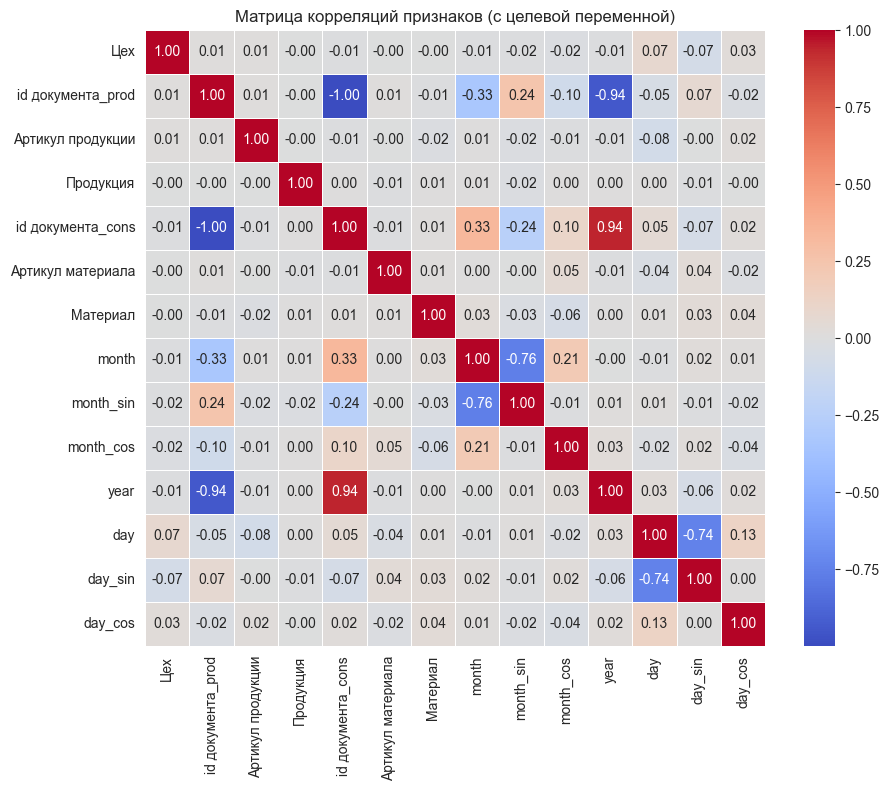

C:\Users\l.d.lagunov\AppData\Local\Temp\ipykernel_10212\2155913691.py:312: UserWarning: Glyph 128315 (\N{DOWN-POINTING RED TRIANGLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\l.d.lagunov\AppData\Local\Temp\ipykernel_10212\2155913691.py:312: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\l.d.lagunov\.conda\envs\pytorch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128315 (\N{DOWN-POINTING RED TRIANGLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\l.d.lagunov\.conda\envs\pytorch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


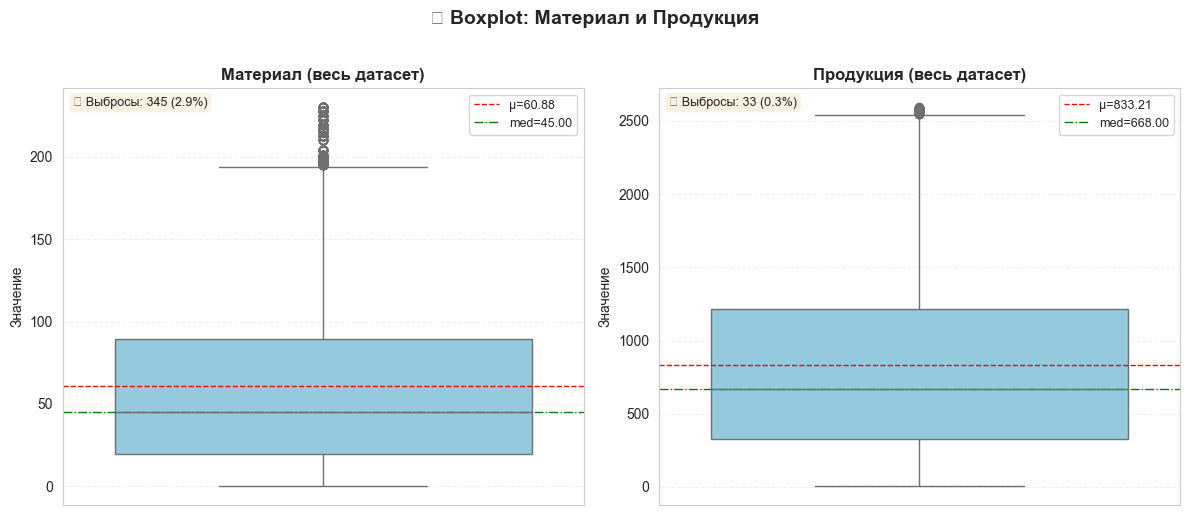


📈 Статистика для (весь датасет):
Колонка               Mean        Med        Std        Min        Max     Outliers
----------------------------------------------------------------------
Материал             60.88      45.00      53.03       0.20     230.00    345 (  2.9%)
Продукция           833.21     668.00     610.29       6.00    2593.00     33 (  0.3%)

📋 ВЕСЬ ДАТАСЕТ

📐 Размерность: 11976 строк × 14 колонок
🎯 Целевая переменная: 'Продукция' (задача: regression)

📦 Типы данных:
   int64: 7 колонки(ок)
   float64: 7 колонки(ок)

✅ Пропущенных значений нет

✅ Дубликатов строк нет

📊 Описательная статистика (числовые признаки):
                     count          mean           std           min           25%           50%           75%           max  missing  unique
Цех                11976.0  5.329026e+02  1.528741e+01  5.110000e+02  5.220000e+02  5.330000e+02  5.440000e+02  5.550000e+02        0       5
id документа_prod  11976.0  9.906717e+09  3.639315e+06  9.900469e+09  9.903

In [31]:
# ✅ Создание датасета с 3 выборками (train/val/test)
dataset = Dataset(
    df, 
    "Продукция", 
    task_type="regression", 
    test_size=0.2,      # 20% на тест
    val_size=0.2,       # 20% от оставшихся на валидацию (~16% от общего)
    random_state=42, 
    categorical_columns=["Цех", "id документа_prod", "id документа_cons", "Артикул продукции", "Артикул материала"], 
    one_hot_encoding=True,
    #one_hot_encoding_columns=[]
)
dataset.scale_features()
dataset.plot_correlation_matrix()
dataset.boxplot()
dataset.print_info()

In [ ]:
# Модели для тестирования
models = ["catboost", "lightgbm", "xgboost",] #"random_forest", "knn"]
results = {}
boost_val_loss_history = {}

In [ ]:
for m in models:
    print(f"\n{'='*60}")
    print(f"Модель: {m}")
    print(f"{'='*60}")
    #boost_loss_history[m] = []
    boost_val_loss_history[m] = []
    
    use_gpu = (m in ['catboost', 'lightgbm', 'xgboost'])
    
    model = MetaModel(dataset, m, model_params="optuna", use_gpu=use_gpu)
    model.train(n_trials=10)  # 50 итераций Optuna
    metrics = model.evaluate()  # ✅ Оценка на TEST (не val!)
    results[m] = metrics[0]  # R² для регрессии

    train_loss, val_loss = model.get_best_trial_history()
    boost_val_loss_history[m] = val_loss
    if train_loss and val_loss:
        plt.figure(figsize=(10, 4))
        plt.plot(train_loss, label='Train Loss', alpha=0.7)
        plt.plot(val_loss, label='Val Loss', alpha=0.7)
        plt.title(f'{m} - Лучший trial #{model.study.best_trial.number}')
        plt.xlabel('Итерация')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
    
    torch.save(model, f'C:\\Users\\l.d.lagunov\\kalashnikov_task1\\models\\{m}.pth')

In [ ]:
    # # ============================================================================
    # # 🧠 ОБУЧЕНИЕ НЕЙРОСЕТИ С VALIDATION
    # # ============================================================================
    # print("\n" + "="*60)
    # print("🧠 ОБУЧЕНИЕ НЕЙРОСЕТИ MLP")
    # print("="*60)
    
    # # ✅ Используем validation для early stopping
    # X_train = torch.FloatTensor(dataset.X_train.values)
    # y_train = torch.FloatTensor(dataset.y_train).view(-1, 1)
    # X_val = torch.FloatTensor(dataset.X_val.values)
    # y_val = torch.FloatTensor(dataset.y_val).view(-1, 1)
    # X_test = torch.FloatTensor(dataset.X_test.values)
    # y_test = torch.FloatTensor(dataset.y_test).view(-1, 1)

    # mlp_model = MLP(dataset.X_count())
    # criterion = nn.HuberLoss(delta=10.0)
    # optimizer = optim.AdamW(mlp_model.parameters(), lr=0.001, weight_decay=1e-4)
    # scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=50)

    # loss_history = []
    # val_loss_history = []
    # best_val_loss = float('inf')
    # patience_counter = 0
    # best_model_state = None

    # mlp_model.train()
    # for epoch in range(500):  
    #     optimizer.zero_grad()
    #     outputs = mlp_model(X_train)
    #     train_loss = criterion(outputs, y_train)
    #     loss_history.append(train_loss.item())
    #     train_loss.backward()
    #     optimizer.step()
        
    #     # ✅ Валидация каждую 5-ю эпоху
    #     if epoch % 5 == 0:
    #         mlp_model.eval()
    #         with torch.no_grad():
    #             val_outputs = mlp_model(X_val)  # ✅ На validation, не test!
    #             val_loss = criterion(val_outputs, y_val)
    #         val_loss_history.append(val_loss.item())
    #         mlp_model.train()
            
    #         scheduler.step(val_loss)
            
    #         # ✅ Early stopping по validation loss
    #         if val_loss < best_val_loss:
    #             best_val_loss = val_loss
    #             patience_counter = 0
    #             best_model_state = {k: v.clone() for k, v in mlp_model.state_dict().items()}
    #         else:
    #             patience_counter += 1
    #             if patience_counter >= 100:
    #                 print(f"⏹️ Early stopping на эпохе {epoch}")
    #                 break
        
    #     if (epoch + 1) % 100 == 0:
    #         print(f'Epoch {epoch+1:4d} | Train: {train_loss.item():.4f} | Val: {val_loss.item():.4f}')

    # # ✅ Загружаем лучшие веса
    # if best_model_state is not None:
    #     mlp_model.load_state_dict(best_model_state)
    #     print("✅ Загружены веса с лучшим validation loss")

    # # ✅ Оценка нейросети на TEST выборке
    # print("\n" + "="*60)
    # print("🧠 ОЦЕНКА НЕЙРОСЕТИ MLP НА TEST ВЫБОРКЕ")
    # print("="*60)
    # mlp_metrics = evaluate_pytorch_model(mlp_model, dataset.X_test, dataset.y_test, task_type='regression')

    # # ============================================================================
    # # 📊 ИТОГОВЫЕ РЕЗУЛЬТАТЫ
    # # ============================================================================
    # print("\n" + "="*60)
    # print("🏆 ИТОГОВЫЕ РЕЗУЛЬТАТЫ (на TEST выборке)")
    # print("="*60)
    
    # results['mlp'] = mlp_metrics['r2']
    # for model_name, score in sorted(results.items(), key=lambda x: x[1], reverse=True):
    #     marker = "🏆" if model_name == max(results, key=results.get) else " "
    #     print(f"{marker} {model_name:15s}: R² = {score:.4f}")

    # best_model = max(results, key=results.get)
    # print(f"\n🏆 Лучшая модель: {best_model}")

    # # График потерь
    # plt.figure(figsize=(12, 5))
    
    # plt.subplot(1, 2, 1)
    # plt.plot(loss_history, label='Train Loss', color='blue', linewidth=1, alpha=0.7)
    # plt.xlabel('Эпоха', fontsize=12)
    # plt.ylabel('Loss', fontsize=12) 
    # plt.title('Динамика ошибки обучения (Train)', fontsize=14)
    # plt.legend()
    # plt.grid(True, alpha=0.3)
    
    # plt.subplot(1, 2, 2)
    # plt.plot(val_loss_history, label='Validation Loss', color='red', linewidth=2)
    # plt.xlabel('Эпоха (каждая 5-я)', fontsize=12)
    # plt.ylabel('Loss', fontsize=12) 
    # plt.title('Динамика ошибки валидации', fontsize=14)
    # plt.legend()
    # plt.grid(True, alpha=0.3)
    
    # plt.tight_layout()
    # plt.show()

    # torch.save(mlp_model, f'C:\\Users\\l.d.lagunov\\kalashnikov_task1\\models\\mlp_model.pth')
    
    # plt.plot(loss_history, label='MLP', color='blue', linewidth=1, alpha=0.7)
    # plt.plot(boost_val_loss_history["catboost"], label='Catboost', color='red', linewidth=1, alpha=0.7)
    # plt.plot(boost_val_loss_history["xgboost"], label='XGBoost', color='green', linewidth=1, alpha=0.7)
    # plt.plot(boost_val_loss_history["lightgbm"], label='Lightgbm', color='yellow', linewidth=1, alpha=0.7)
    # plt.xlabel('Эпоха (каждая 5-я)', fontsize=12)
    # plt.ylabel('Loss', fontsize=12) 
    # plt.title('Динамика ошибки валидации', fontsize=14)
    # plt.legend()
    # plt.tight_layout()
    # plt.show()

In [ ]:
# ============================================================================
# 📈 ВИЗУАЛИЗАЦИЯ ПОТЕРЬ БУСТИНГОВЫХ МОДЕЛЕЙ (для Jupyter Notebook)
# ============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import warnings

warnings.filterwarnings('ignore')

# Настройки графика
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# ============================================================================
# 🔧 Настройки путей
# ============================================================================
MODELS_DIR = r'C:\Users\l.d.lagunov\kalashnikov_task1\models'
MODELS_TO_LOAD = ['catboost', 'lightgbm', 'xgboost']

# ============================================================================
# 📦 Функция загрузки истории из сохранённой модели
# ============================================================================
def load_loss_history(model_path, model_name):
    """
    Загружает сохранённую модель и извлекает историю потерь.
    ✅ MetaModel уже доступен в Jupyter Notebook (не нужно импортировать)
    """
    if not os.path.exists(model_path):
        print(f"⚠️ Файл не найден: {model_path}")
        return None, None, None
    
    try:
        # ✅ В Jupyter Notebook класс MetaModel уже доступен в kernel
        model = torch.load(model_path, map_location='cpu', weights_only=False)
        
        # Извлекаем историю из MetaModel
        if hasattr(model, 'val_loss_history') and model.val_loss_history:
            best_trial_num = model.study.best_trial.number if hasattr(model, 'study') and model.study else 0
            
            train_losses = model.train_loss_history.get(best_trial_num, [])
            val_losses = model.val_loss_history.get(best_trial_num, [])
            
            print(f"✅ {model_name}: загружено {len(val_losses)} точек валидации")
            return train_losses, val_losses, model.study
        else:
            print(f"⚠️ {model_name}: история потерь не найдена в модели")
            return [], [], None
            
    except Exception as e:
        print(f"❌ Ошибка загрузки {model_name}: {e}")
        return None, None, None


# ============================================================================
# 🎨 Функция построения графика
# ============================================================================
def plot_losses(train_losses, val_losses, model_name, trial_number, ax=None, color=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(14, 6))
    
    iterations = range(len(val_losses))
    
    if len(train_losses) != len(val_losses):
        if len(train_losses) > len(val_losses):
            train_losses = train_losses[:len(val_losses)]
    
    ax.plot(iterations, val_losses, label='Validation Loss', color=color or 'red', linewidth=2, marker='o', markersize=3)
    
    if train_losses and len(train_losses) == len(val_losses):
        ax.plot(iterations, train_losses, label='Train Loss', color=color or 'blue', linewidth=1, alpha=0.7, marker='.', markersize=2)
    
    ax.set_xlabel('Итерация бустинга', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title(f'{model_name.upper()} — Trial #{trial_number}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    return ax


# ============================================================================
# 🔄 Функция нормализации потерь для сравнения
# ============================================================================
def normalize_for_comparison(losses_dict, method='sqrt'):
    result = {}
    
    for name, losses in losses_dict.items():
        losses = np.array(losses)
        
        if method == 'sqrt' and name == 'lightgbm':
            # LightGBM по умолчанию использует l2 (MSE), берём корень → RMSE
            result[name] = np.sqrt(np.clip(losses, 1e-10, None))
        elif method == 'log':
            result[name] = np.log1p(losses)
        elif method == 'minmax':
            result[name] = (losses - losses.min()) / (losses.max() - losses.min() + 1e-8)
        else:
            result[name] = losses
    
    return result


# ============================================================================
# 🚀 Основная функция
# ============================================================================
def main():
    print("=" * 70)
    print("📊 ВИЗУАЛИЗАЦИЯ ПОТЕРЬ БУСТИНГОВЫХ МОДЕЛЕЙ")
    print("=" * 70)
    
    all_losses = {}
    studies = {}
    
    print("\n📦 Загрузка моделей...")
    for model_name in MODELS_TO_LOAD:
        model_path = os.path.join(MODELS_DIR, f'{model_name}.pth')
        train_loss, val_loss, study = load_loss_history(model_path, model_name)
        
        if val_loss is not None and len(val_loss) > 0:
            all_losses[model_name] = {'train': train_loss, 'val': val_loss}
            studies[model_name] = study
            print(f"   ✓ {model_name}: {len(val_loss)} точек")
        else:
            print(f"   ✗ {model_name}: пропущен")
    
    if not all_losses:
        print("\n❌ Не удалось загрузить ни одной модели.")
        print("\n💡 Убедитесь, что:")
        print("   1. Класс MetaModel определён в этом же Notebook (в ячейке выше)")
        print("   2. Модели сохранены в правильном пути")
        return
    
    # ========================================================================
    # 📈 Часть 1: Отдельные графики для каждой модели
    # ========================================================================
    print("\n📊 Построение отдельных графиков...")
    
    colors = {'catboost': '#ff6b6b', 'lightgbm': '#4ecdc4', 'xgboost': '#45b7d1'}
    
    for model_name in MODELS_TO_LOAD:
        if model_name not in all_losses:
            continue
        
        data = all_losses[model_name]
        study = studies[model_name]
        trial_num = study.best_trial.number if study else 0
        
        fig, ax = plt.subplots(1, 1, figsize=(14, 6))
        plot_losses(data['train'], data['val'], model_name, trial_num, ax=ax, color=colors.get(model_name))
        
        if study:
            best_value = study.best_value
            ax.text(0.02, 0.98, f'Best Value: {best_value:.4f}', 
                   transform=ax.transAxes, fontsize=10, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
        
        plt.tight_layout()
        plt.show()
        
        save_path = os.path.join(MODELS_DIR, f'{model_name}_loss_curve.png')
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"   💾 Сохранено: {save_path}")
        plt.close(fig)
    
    # ========================================================================
    # 📊 Часть 2: Общий сравнительный график (3 подграфика вместо 4)
    # ========================================================================
    print("\n🔍 Построение общего сравнительного графика...")
    
    # ✅ УБРАН график с разными метриками (axes[0,0]), теперь 3 графика в ряду 2x2
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('Сравнение бустинговых моделей — динамика потерь', fontsize=16, fontweight='bold', y=1.02)
    
    # ─── График 1: Приведено к RMSE (рекомендуемый) ────────────────────────
    ax = axes[0, 0]
    normalized = normalize_for_comparison({k: v['val'] for k, v in all_losses.items()}, method='sqrt')
    
    for model_name in MODELS_TO_LOAD:
        if model_name not in normalized:
            continue
        losses = normalized[model_name]
        iterations = range(len(losses))
        ax.plot(iterations, losses, label=f'{model_name.upper()} (RMSE)', 
               color=colors.get(model_name, 'gray'), linewidth=2.5, alpha=0.95, marker='.', markersize=2)
    
    ax.set_xlabel('Итерация бустинга', fontsize=11)
    ax.set_ylabel('Loss (RMSE)', fontsize=11)
    ax.set_title('✅ Все метрики в RMSE (рекомендуется)', fontsize=12, fontweight='bold', color='darkgreen')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # ─── График 2: Логарифмическая шкала ────────────────────────────────────
    ax = axes[0, 1]
    for model_name in MODELS_TO_LOAD:
        if model_name not in all_losses:
            continue
        val_loss = np.array(all_losses[model_name]['val'])
        iterations = range(len(val_loss))
        safe_loss = np.clip(val_loss, 1e-10, None)
        ax.semilogy(iterations, safe_loss, label=model_name.upper(), 
                   color=colors.get(model_name, 'gray'), linewidth=2, alpha=0.9)
    
    ax.set_xlabel('Итерация', fontsize=11)
    ax.set_ylabel('Loss (log scale)', fontsize=11)
    ax.set_title('📉 Логарифмическая шкала для большого диапазона', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--', which='both')
    ax.set_axisbelow(True)
    
    # ─── График 3: Финальные значения (бар-чарт) ────────────────────────────
    ax = axes[1, 0]
    
    final_rmse = {}
    for model_name in MODELS_TO_LOAD:
        if model_name not in all_losses:
            continue
        val_loss = np.array(all_losses[model_name]['val'])
        if model_name == 'lightgbm':
            final_rmse[model_name] = np.sqrt(val_loss[-1])
        else:
            final_rmse[model_name] = val_loss[-1]
    
    sorted_models = sorted(final_rmse.items(), key=lambda x: x[1])
    names = [m[0].upper() for m in sorted_models]
    values = [m[1] for m in sorted_models]
    bar_colors = [colors.get(m[0].lower(), 'gray') for m in sorted_models]
    
    bars = ax.barh(names, values, color=bar_colors, alpha=0.8, edgecolor='black')
    
    for bar, val in zip(bars, values):
        ax.text(val + val*0.01, bar.get_y() + bar.get_height()/2, 
               f'{val:.2f}', va='center', fontsize=10, fontweight='bold')
    
    ax.set_xlabel('Final Loss (RMSE)', fontsize=11)
    ax.set_title('🏆 Финальные значения потерь (меньше = лучше)', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--', axis='x')
    ax.set_axisbelow(True)
    
    best_model = sorted_models[0][0].upper()
    ax.text(0.5, -0.15, f'🏆 Лучшая модель: {best_model}', 
           transform=ax.transAxes, fontsize=13, fontweight='bold', 
           ha='center', bbox=dict(boxstyle='round', facecolor='gold', alpha=0.4))
    
    # ─── График 4: Пустой (убираем лишнее) ──────────────────────────────────
    ax = axes[1, 1]
    ax.axis('off')  # ✅ Отключаем пустой график
    
    plt.tight_layout()
    plt.show()
    
    save_path = os.path.join(MODELS_DIR, 'boosting_comparisonn.png')
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"   💾 Сохранено: {save_path}")
    plt.close(fig)
    
    # ========================================================================
    # 📋 Часть 3: Текстовая сводка
    # ========================================================================
    print("\n" + "=" * 70)
    print("📋 СВОДКА ПО МОДЕЛЯМ")
    print("=" * 70)
    
    summary_data = []
    for model_name in MODELS_TO_LOAD:
        if model_name not in all_losses:
            continue
        
        val_loss = np.array(all_losses[model_name]['val'])
        final_loss = val_loss[-1]
        
        if model_name == 'lightgbm':
            display_loss = np.sqrt(final_loss)
            metric_note = "(MSE→RMSE)"
        else:
            display_loss = final_loss
            metric_note = "(RMSE)"
        
        summary_data.append({
            'Model': model_name.upper(),
            'Final Loss (RMSE)': f'{display_loss:.3f}',
            'Note': metric_note,
            'Iterations': len(val_loss)
        })
    
    df_summary = pd.DataFrame(summary_data)
    df_summary = df_summary.sort_values('Final Loss (RMSE)', key=lambda x: x.str.replace(',', '.').astype(float))
    
    print(df_summary.to_string(index=False))
    
    print(f"\n💡 Подсказка: Меньшее значение потери = лучше качество модели")
    print(f"💡 LightGBM использовал MSE, поэтому был конвертирован в RMSE для сравнения")
     
    print("\n✨ Готово!")


# ============================================================================
# 🏁 Запуск (для Jupyter Notebook)
# ============================================================================
main()

In [ ]:
data_to_process = pd.read_csv("kalashnikov_task1/Sintez_dannykh_zadacha_1.csv", encoding='cp1251', sep=';')
model = torch.load('kalashnikov_task1\models\lightgbm.pth')

print(next(data_to_process.itertuples()))


columns = ['Артикул материала', 'Наименование материала', 'Цех']
columns.extend(data_to_process.columns[3:])

output_data = pd.DataFrame(columns=columns)

for row in data_to_process.itertuples():
    #index = row.Index
    articul_material = getattr(row, 'Артикул материала')
    name_material = row.Наименование_материала
    ceh = row.Цех
    material_count = list(row)[3:]
    